In [1]:
import matplotlib.pyplot as plt
import datetime
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import os
import h5py
from h5flow.data import dereference 
import yaml
import csv
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from DrawEvent import *
from BiPoSelection import *

In [ ]:
# CL and light file paths 
CL_775_p1 = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_CLmatching_low_energy/flowed_light_low_energy_v3/source_rn_bin1/injection/packet-0060156-2025_11_20_20_06_56_CST_mpd_run_data_rctl_775_p2_CLmatched.FLOW_LE.hdf5'
# need this for the h5 file waveforms
flow_light_775_p1 = '/global/cfs/cdirs/dune/users/mlopuszanski/radon_injections/mpd_run_data_rctl_775_p2.FLOW.hdf5'
# npy file for the fpromt and integral of a hit on sum waveforms 
# can also be taken from ndlar flow but this had a bug when i was using it
light_775_p1 = '/global/cfs/cdirs/dune/users/mlopuszanski/Rn_injection/results/mpd_run_data_rctl_775_p2.FLOW_sum_hits_results.npy'

h5 = h5py.File(flow_light_775_p1, 'r')
# different waveforms
swvfm = h5['light/swvfm/data']['samples']
wvfm = h5['light/wvfm/data']['samples']
stpc_wvfm = h5['light/stpc_wvfm/data']['samples']
# references between hits and events
sum_tpc_hits = h5['light/sum_tpc_hits/data']
sum_tpc_hits_refs = h5['light/events/ref/light/sum_tpc_hits/ref']

# data for sum_hits 
hit_data = np.load(light_775_p1, allow_pickle=True).item() 
sum_hits_refs = hit_data['refs']
fprompt = hit_data['fprompt']
integral = hit_data['integral']
maxA = hit_data['max']
trap_type = hit_data['det']
tpc = hit_data['tpc']
sample_index = hit_data['sample_idx']
sum_hit_id = hit_data['id']

# data for tpc_hits
light_775_p1_tpc = '/global/cfs/cdirs/dune/users/mlopuszanski/Rn_injection/results/mpd_run_data_rctl_775_p1.FLOW_tpc_hits_results.npy'
tpc_hit_data_fprompt = np.load(light_775_p1, allow_pickle=True).item() 
fprompt_tpc = hit_data['fprompt']


dict_keys(['max', 'integral', 'fprompt', 'tpc', 'det', 'refs', 'id', 'sample_idx', 'event', 'trap_type', 'start_time', 'length'])
Found 469 light events with multiple hits in one wvfm
Found 3909 light events matched to charge cluster
Found 363 events with multiple hits in one wvfm AND matched charge


Finding the hit pairs in the run 

The functions are explained in BiPoSelection.py

In [9]:
# finding BiPos in sum_tpc_hits
hit_pairs, events_with_nhits, dt_list = calculate_dt(sum_tpc_hits, sum_tpc_hits_refs, 'tpc')
print(f'Found {len(hit_pairs)} light events with multiple hits in one wvfm')

matched_CLevents  = get_reconstructed_position(CL_775_p1)
matched_light = matched_CLevents.keys()
print(f'Found {len(matched_light)} light events matched to charge cluster')

matched_nhit_events = [e for e in events_with_nhits if e in matched_CLevents]
print(f'Found {len(matched_nhit_events)} events with multiple hits in one wvfm AND matched charge')

Found 469 light events with multiple hits in one wvfm
Found 3909 light events matched to charge cluster
Found 363 events with multiple hits in one wvfm AND matched charge


Necessary geometry information to plot the tpcs and light traps

In [3]:
#We can load the detector center position and the SiPM position from the geometry 
lrs_geometry_file = '/global/cfs/cdirs/dune/users/mlopuszanski/ndlar_flow/data/proto_nd_flow/light_module_desc-5.0.1.yaml'
with open(lrs_geometry_file) as gf:
    lrs_geometry_yaml = yaml.load(gf, Loader=yaml.FullLoader)

tpc_ids =  np.array([v for v in lrs_geometry_yaml['tpc_center_offset'].keys()])
det_ids = np.array([v for v in lrs_geometry_yaml['det_center'].keys()])


det_type_array = np.zeros((len(tpc_ids), len(det_ids)), dtype=np.int32)
for i, tpc in enumerate(tpc_ids):
    for j, det in enumerate(det_ids):
        det_type = lrs_geometry_yaml['det_geom'][tpc][det]
        det_type_array[i,j] = det_type

tpc_bounds = extract_tpc_bounds(h5py.File(CL_775_p1))

### Choose event here

In [5]:
EVENT=5943
print(f'Event {EVENT}')


### LIGHT 
# find all the hits that are found in the BiPo event
hits_in_event, num_hits = get_hits_in_event(EVENT, hit_data['refs'])
print(f'Light hits in event {EVENT}: {num_hits}')


# array to store the tpc/det info about the hit
hit_det = np.zeros((num_hits, 2), dtype=np.int16)
# initialise as list of lists instead of np.full
hit_location = [[[] for _ in range(16)] for _ in range(8)]
hit_integral = np.full((8, 16), 0.0)
light_tpcs=[]

# fill array
for i, h in enumerate(hits_in_event):
    tpc_h = int(hit_data['tpc'][h])
    light_tpcs.append(tpc_h)
    det_h = int(hit_data['det'][h])
    hit_location[tpc_h][det_h].append(h)
    hit_integral[tpc_h, det_h] += hit_data['integral'][h]  # sum integrals

# unique tpcs for light
tpc_light_hit = np.unique(light_tpcs)

### CHARGE CLUSTER
# get the coordinates from the cluster 
x_cluster = matched_CLevents[EVENT]['x']
print(len(x_cluster))
y_cluster = matched_CLevents[EVENT]['y']
z_cluster = matched_CLevents[EVENT]['z']
x_anode_cluster = matched_CLevents[EVENT]['x_anode']
charge_cluster = matched_CLevents[EVENT]['charge']
# assign it to a TPC based on the position
tpc_cluster = []
for x_anode, x_val, y_val, z_val in zip(x_anode_cluster, x_cluster, y_cluster, z_cluster):
    tpc_cluster.append(get_tpc_from_xz(x_val, z_val, tpc_bounds))
    # tpc_cluster.append(get_tpc_from_xz(x_anode, z_val, tpc_bounds))
# find in how many tpc light or charge are seen 
tpcs_to_draw = np.unique(np.append(tpc_light_hit ,tpc_cluster))
print('tpcs to draw', tpcs_to_draw)

# map axes to a TPC
ax_to_tpc = np.full((len(tpcs_to_draw), 2), -1)
for i, tpc in enumerate(tpcs_to_draw):
    ax_to_tpc[i, 0] = i
    ax_to_tpc[i, 1] = tpc
print('ax_to_tpc', ax_to_tpc)

tpc_to_ax = {tpc: i for i, tpc in enumerate(tpcs_to_draw)}
print('tpc_to_ax', tpc_to_ax)


Event 5943
Light hits in event 5943: 10
1
tpcs to draw [7]
ax_to_tpc [[0 7]]
tpc_to_ax {np.int64(7): 0}


Plotting the TPC

<class 'list'>


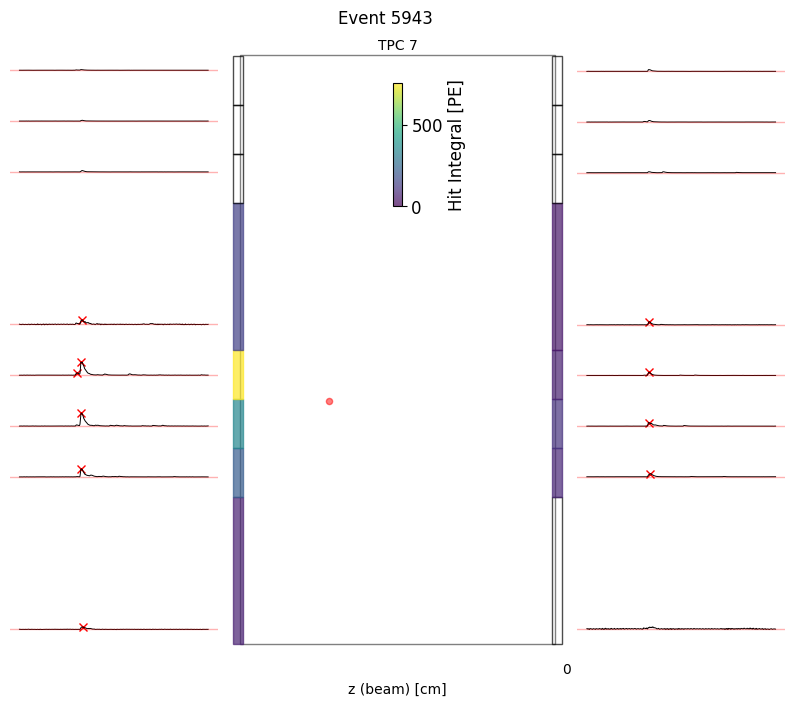

In [6]:

# DRAW SIDE VIEW (ZY PLANE)
# Normalize hit charges for coloring
max_integral = np.max(hit_integral)
min_integral = np.min(0)  # Exclude zeros

cmap = plt.cm.viridis  # or 'plasma', 'inferno', 'hot', etc.
norm = plt.Normalize(vmin=min_integral, vmax=max_integral)


LEFT_DETS  = list(range(8))    # det_id 0-7
RIGHT_DETS = list(range(8, 16)) # det_id 8-15


# --- PREPARING FIGURE ---
fig = plt.figure(figsize=(10, 8))

gs = GridSpec(
    len(tpcs_to_draw), 3,      # rows=n TPCs, cols=left wvfm | TPC view | right wvfm
    width_ratios=[1, 2, 1],    # waveform panels narrower than TPC view
    hspace=0.0,
    wspace=-0.1
)

ax_tpc   = [fig.add_subplot(gs[i, 1], frame_on=False) for i in range(len(tpcs_to_draw))]
ax_left  = [fig.add_subplot(gs[i, 0], frame_on=False) for i in range(len(tpcs_to_draw))]
ax_right = [fig.add_subplot(gs[i, 2], frame_on=False) for i in range(len(tpcs_to_draw))]


# --- PLOTTING TPC ---
for i, tpc in enumerate(tpcs_to_draw):
    ax = ax_tpc[i]
    bounds = tpc_bounds[tpc]

    # draw tpc outline
    bounds = tpc_bounds[tpc]
    draw_tpc_side(ax, bounds, tpc, set_axis_limit=True)
    

    # draw individual detectors
    tpc_shift = np.mean(bounds, axis=0)
    for det_id in sorted(lrs_geometry_yaml['det_center'].keys(), key=int):
        # position of the corners of det d on tpc t
        plate_corners = get_plate_corners(int(det_id), tpc_shift, lrs_geometry_yaml)
        z_center = np.mean(plate_corners[:, 2])  # adjust indices for zy plane
        y_center = np.mean(plate_corners[:, 1])

        if hit_location[tpc][det_id]:
            # h_idx = hit_location[tpc, det_id]
            integral = hit_integral[tpc, det_id]
            fill=True
            facecolor = cmap(norm(integral))     
        else:
            fill=False
            facecolor=None  
        
        draw_det_outline(ax, plate_corners, det_id, plane='zy',
                            fill=fill, facecolor=facecolor, edgecolor=facecolor)

    # draw the cluster into the zy view
    for x_anode, y_val, z_val, tpc_val in zip(x_anode_cluster, y_cluster, z_cluster, tpc_cluster):
        ax_idx = tpc_to_ax[tpc_val]
        print(type(ax_tpc))
        ax_tpc[ax_idx].scatter(z_val, y_val, color='red', zorder=5, s=20, alpha=0.5)
    



# --- PLOTTING WAVEFORMS ---
for i, tpc in enumerate(tpcs_to_draw):
    for ax, det_ids, side in zip([ax_left[i], ax_right[i]], 
                                 [LEFT_DETS,   RIGHT_DETS],
                                 ['left',      'right']):

        for det_id in det_ids:
            waveform = waveform = swvfm[EVENT][tpc][det_id]

            plate_corners = get_plate_corners(int(det_id), tpc_shift, lrs_geometry_yaml)
            
            # plate_height=10
            # waveform_scaled = y_center + (waveform / waveform.max() * plate_height * 0.8 
            #                                 if waveform.max() > 0 else waveform)

            waveform_scaled = np.min(plate_corners[:,1]) + (waveform/10) - 5
            if hit_location[tpc][det_id]:
                h_id = hit_location[tpc][det_id]
                sample_idx = hit_data['sample_idx'][h_id]
                ax.plot(sample_idx, waveform_scaled[sample_idx], 'rx', label='Hit')

            color='black'
            ax.plot(waveform_scaled, color=color, lw=0.7)
            ax.axhline(np.min(plate_corners[:,1]) - 5, color='red', lw=1, alpha=0.3)  # baseline per det
            ax.set_axis_off()
        
            


for ax in ax_tpc:
    # ax.set_axis_off()
    ax.set_ylim(-65, 65)
    ax.tick_params(axis='both', which='both',length=0)
    ax.set_yticks([])
    ax.set_xticks([0])


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable
# cbar = fig.colorbar(sm, ax=ax_tpc, label='Hit Integral [PE]',  shrink=0.4, location='bottom')  # ax=ax makes it span both subplots
# Replace the fig.colorbar line with:
# Choose which axis to place it in, e.g. the last TPC axis
cax = inset_axes(ax_tpc[-1],
                 width="2%",    # width of colorbar relative to parent axis
                 height="20%",    # height
                 loc='upper center',  # position inside the axis
                 borderpad=3)

cbar = fig.colorbar(sm, cax=cax, orientation='vertical', label='Hit Integral [PE]', alpha=0.7)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Hit Integral [PE]', fontsize=12)


fig.suptitle(f'Event {EVENT}', position=(0.5,0.92))
plt.show()


TPC waveforms 

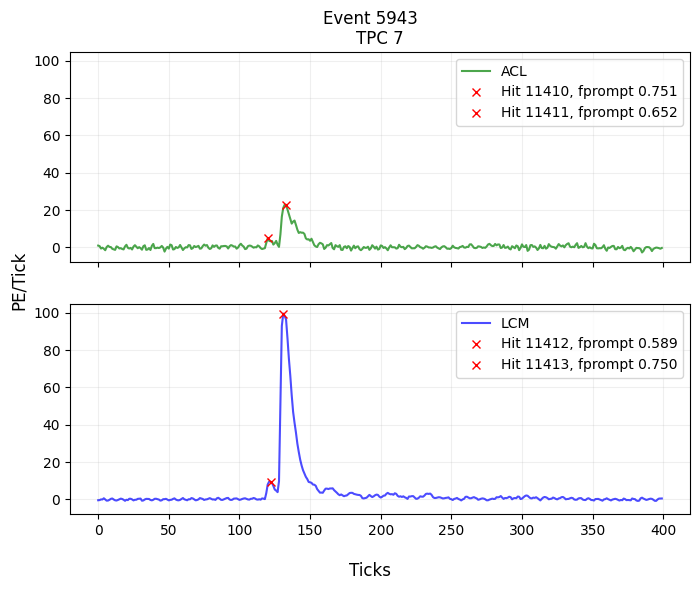

In [7]:

wvfm_data = stpc_wvfm
tpc_hits=sum_tpc_hits

hits_in_event, num_hits = get_hits_in_event(EVENT, sum_tpc_hits_refs)

for i, tpc in enumerate(tpcs_to_draw):
    
    fig, axes = plt.subplots(2, 1,  figsize=(8, 6), 
                             sharey=True, sharex=True)
    
    axes[0].set_title(f"TPC {tpc}")

    wvfm_acl = wvfm_data[EVENT][tpc][0]
    wvfm_lcm = wvfm_data[EVENT][tpc][1]

    # ax_acl[i].plot(wvfm_acl, color='green', label='ACL', alpha=0.7)
    # ax_lcm[i].plot(wvfm_lcm, color='blue', label='LCM', alpha=0.7)

    # plot the wvfms of an event
    axes[0].plot(wvfm_acl, color='green', label='ACL', alpha=0.7)
    axes[1].plot(wvfm_lcm, color='blue', label='LCM', alpha=0.7)
    

    for h in hits_in_event:
  
        if sum_tpc_hits['trap_type'][h]==0:

            sample_idx = tpc_hits['sample_idx'][h]
            axes[0].plot(sample_idx, wvfm_acl[sample_idx], 'rx', 
                         label=f'Hit {h}, fprompt {fprompt_tpc[h]:.3f}')
            # axes[0].fill_between(x_short, wvfm_acl[t0_bin:t0_bin+prompt_bins], color='red', alpha=0.5, label='200ns window')
            # axes[0].fill_between(x_long, wvfm_acl[t0_bin:t0_bin+total_bins],  color='red', alpha=0.2, label='3200ns window')
        elif sum_tpc_hits['trap_type'][h]==1:

            sample_idx = tpc_hits['sample_idx'][h]
            axes[1].plot(sample_idx, wvfm_lcm[sample_idx], 'rx',
                         label=f'Hit {h}, fprompt {fprompt_tpc[h]:.3f}')
            # axes[1].fill_between(x_short, wvfm_lcm[t0_bin:t0_bin+prompt_bins], color='red', alpha=0.5, label='200ns window')
            # axes[1].fill_between(x_long, wvfm_lcm[t0_bin:t0_bin+total_bins], color='red', alpha=0.2, label='3200ns window')
    
    


    for ax in axes:
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.2)

    fig.suptitle(f'Event {EVENT}', y = 0.95)
    fig.supxlabel('Ticks',y=0.0)
    fig.supylabel('PE/Tick',x=0.05)
        
        

Plotting all detector waveforms for one event

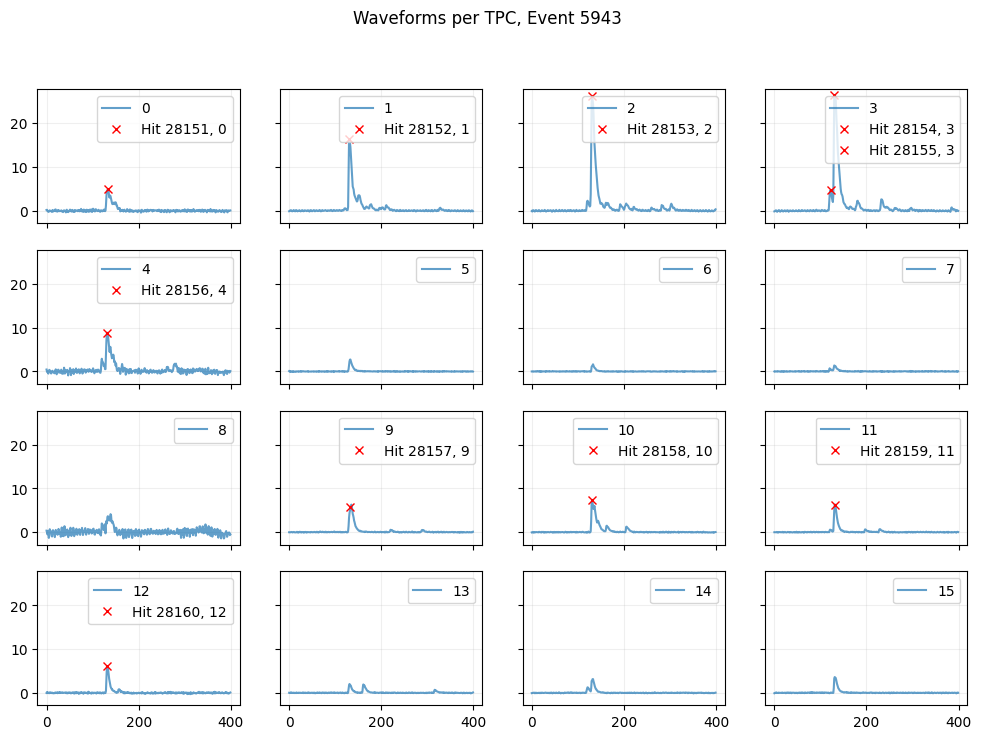

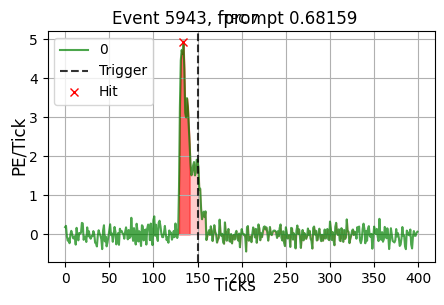

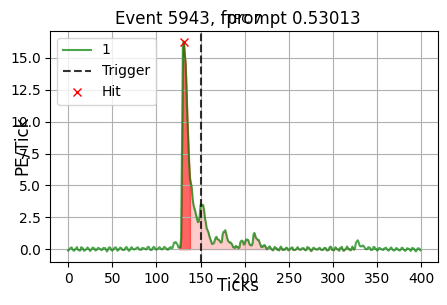

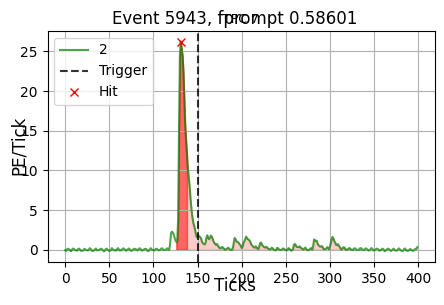

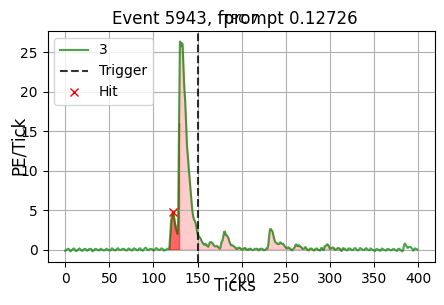

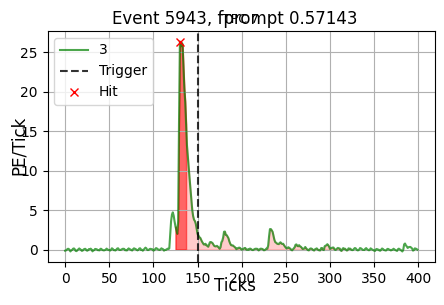

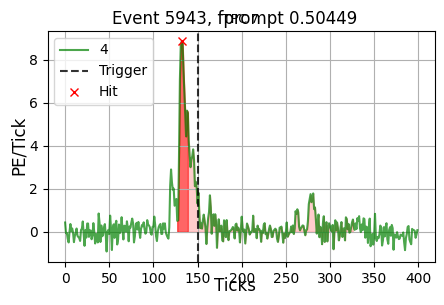

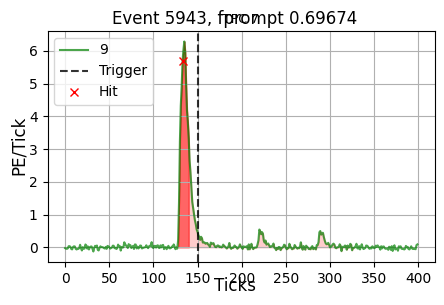

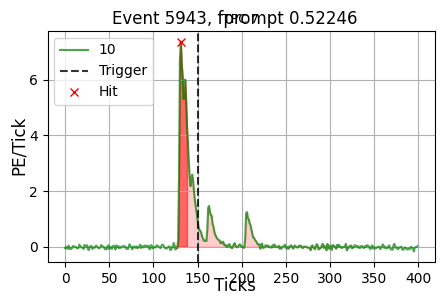

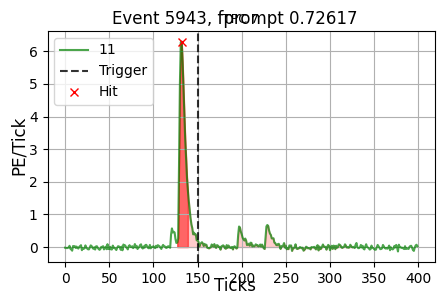

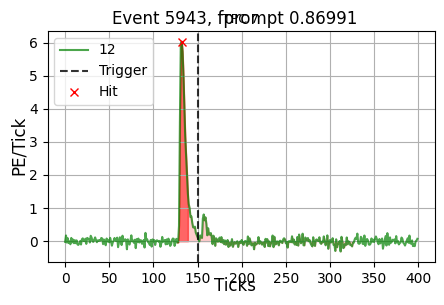

In [8]:

TPC=tpcs_to_draw[0]
fig, axes = plt.subplots(4, 4, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to 1D list for easy indexing

hits_in_event, num_hits = get_hits_in_event(EVENT, hit_data['refs'])

plotByTPCswvfm(fig, axes, swvfm, TPC, EVENT, hits_in_event, hit_data)
for ax in axes: 
    ax.legend()
    # ax.set_ylim(0,10)
    # ax.set_ylim(-1,1)
plt.show()


for i in hits_in_event:
    hit = i

    # get the event corresponding to the hit
    event = sum_hits_refs[hit][0]

    # get the tpc where the hit is in 
    tpc = hit_data['tpc'][hit]
    det = hit_data['det'][hit]

    # plot the waveform
    plot_wvfm(hit_data,  swvfm, fprompt, hit=hit, event=event,tpc=tpc, det=det)